#### Import required python packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### Import sample data and drop uneccessary columns

In [3]:
data_for_model = pd.read_csv("data/sample_data_pca.csv")
print(data_for_model)

     user_id  purchased_album  artist1  artist2  artist3  artist4  artist5  \
0          1                1   0.0000   0.0891      0.0      0.0   0.0000   
1          2                0   0.0000   0.0000      0.0      0.0   0.0000   
2          3                1   0.0002   0.0000      0.0      0.0   0.0000   
3          4                1   0.0000   0.0000      0.0      0.0   0.0000   
4          5                1   0.0006   0.0000      0.0      0.0   0.0000   
..       ...              ...      ...      ...      ...      ...      ...   
351      352                1   0.0000   0.0000      0.0      0.0   0.0000   
352      353                1   0.0000   0.0000      0.0      0.0   0.1759   
353      354                1   0.0000   0.0000      0.0      0.0   0.0000   
354      355                1   0.0000   0.0000      0.0      0.0   0.0000   
355      356                1   0.0001   0.0000      0.0      0.0   0.0000   

     artist6  artist7  artist8  ...  artist91  artist92  artist

In [4]:
data_for_model.drop("user_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['purchased_album', 'artist1', 'artist2', 'artist3', 'artist4',
       'artist5', 'artist6', 'artist7', 'artist8', 'artist9',
       ...
       'artist91', 'artist92', 'artist93', 'artist94', 'artist95', 'artist96',
       'artist97', 'artist98', 'artist99', 'artist100'],
      dtype='object', length=101)


#### Shuffle data

In [7]:
data_for_model = shuffle(data_for_model, random_state = 42)

#### Class balance

In [6]:
data_for_model["purchased_album"].value_counts(normalize = True)

purchased_album
1    0.533708
0    0.466292
Name: proportion, dtype: float64

#### Dealing with missing values

In [8]:
data_for_model.isna().sum().sum()
data_for_model.dropna(how = "any", inplace = True)

#### Split Input variables and Output variables

In [9]:
X = data_for_model.drop(["purchased_album"], axis = 1)
y = data_for_model["purchased_album"]

#### Split out training and test sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

#### Feature scaling

In [12]:
scale_standard = StandardScaler()

X_train = scale_standard.fit_transform(X_train)
X_test = scale_standard.transform(X_test)

## Apply PCA

#### Instantiate and fit

In [13]:
pca = PCA(n_components = None, random_state = 42)
pca.fit(X_train)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


#### Extract the explained variance across components

In [14]:
explained_variance = pca.explained_variance_ratio_
explained_variance_cumulative = pca.explained_variance_ratio_.cumsum()

## Plot the explained variance across components

#### Create list for number of components

In [15]:
num_vars_list = list(range(1,101))
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

#### Plot the variance explained by each component

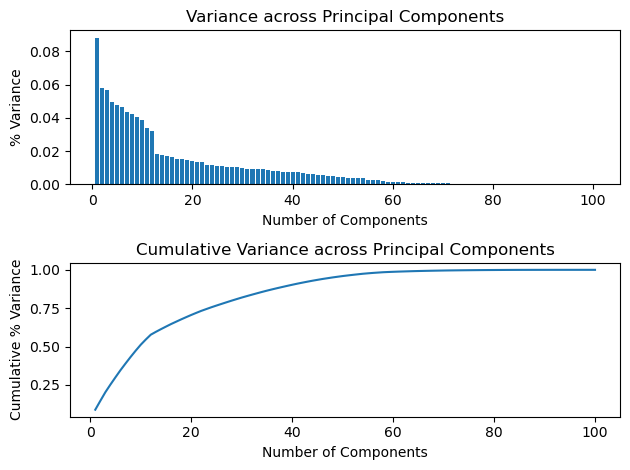

In [17]:
plt.subplot(2,1,1)
plt.bar(num_vars_list,explained_variance)
plt.title("Variance across Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("% Variance")
plt.tight_layout()

# Plot the cumulative variance

plt.subplot(2,1,2)
plt.plot(num_vars_list,explained_variance_cumulative)
plt.title("Cumulative Variance across Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative % Variance")
plt.tight_layout()
plt.show()

## Apply PCA with selected number of components

In [18]:
pca = PCA(n_components = 0.75, random_state = 42)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## Apply PCA with classifier

In [20]:
clf = RandomForestClassifier(random_state = 42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Assess model accuracy

In [21]:
y_pred_class = clf.predict(X_test)
accuracy_score(y_test, y_pred_class)

0.9166666666666666